In [1]:
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt, os

### load dfs/csvs

In [2]:
data_dir = '../data/csvs'

df_all_clean_data = pd.read_parquet(f'{data_dir}/df_all_clean_data.parquet')
df_spikes_z = pd.read_parquet(f'{data_dir}/df_spikes_z.parquet')
valid_mask = np.load(f'{data_dir}/valid_mask.npy')
bin_size = float(df_spikes_z.columns[1] - df_spikes_z.columns[0])  # inferred from column timestamps

# sort all data by region so rows are consistently ordered throughout
sort_order = df_all_clean_data['region'].argsort().values
df_all_clean_data = df_all_clean_data.iloc[sort_order].reset_index(drop=True)
df_spikes_z       = df_spikes_z.iloc[sort_order].reset_index(drop=True)
valid_mask        = valid_mask[sort_order]
regions           = df_all_clean_data['region'].values  # shape: (n_neurons,), str, sorted

print(f"df_spikes_z:  {df_spikes_z.shape}")
print(f"valid_mask: {valid_mask.shape}")
print()
for region in sorted(set(regions)):
    print(f"{region}: {(regions == region).sum()} neurons")

df_all_clean_data[['region', 'neur_id', 'enc_firing_rate']]


df_spikes_z:  (1123, 957)
valid_mask: (1123, 957)

ACC: 190 neurons
amygdala: 335 neurons
hippocampus: 201 neurons
preSMA: 244 neurons
vmPFC: 153 neurons


,region,neur_id,enc_firing_rate
0,ACC,P58CS_R1_34_4_3301_5,17.235694
1,ACC,P51CS_R2_40_2_2540_5,0.604578
2,ACC,P51CS_R2_40_3_2542_5,2.960130
3,ACC,P51CS_R1_8_1_584_5,0.905821
4,ACC,P51CS_R1_34_1_872_6,1.025063
...,...,...,...
1118,vmPFC,P54CS_R1_70_1_5052_10,1.489479
1119,vmPFC,P53CS_R2_65_1_1261_10,1.698675
1120,vmPFC,P53CS_R1_78_1_2468_9,1.215431
1121,vmPFC,P54CS_R1_73_2_1179_9,1.106649


### single-units

For each neuron, compute the normalized autocorrelation at lags 0–`max_lag` s:
1. **Zero gap bins** — bins outside valid recording periods are set to 0 so they contribute nothing to the dot product.
2. **Sliding dot product** — `np.correlate(x, x, 'full')` computes $c[k] = \sum_t x[t]\, x[t-k]$ for all lags; we take the non-negative half (lag 0 onward).
3. **Unbiased correction** — divide each lag's raw sum by its overlap count $(T - k)$, otherwise large lags are artificially deflated because fewer pairs contribute.

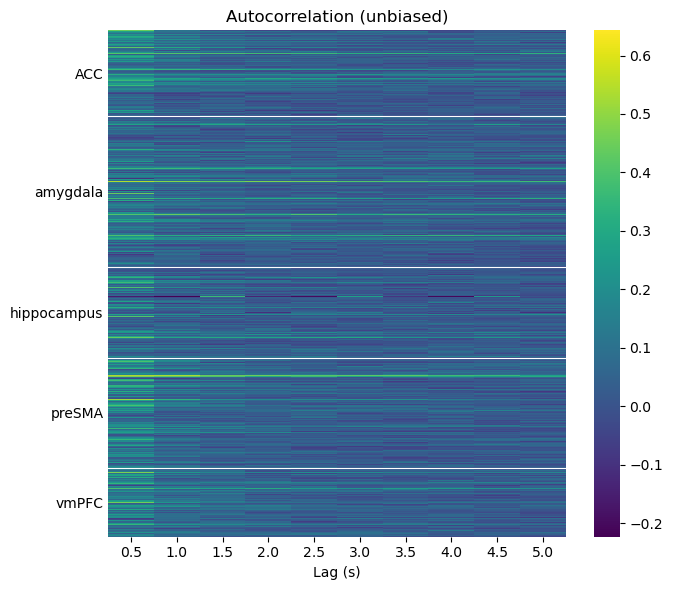

In [5]:
max_lag_s = 5  # max lag in seconds
max_lag_bins = int(max_lag_s / bin_size)  # number of bins

# create spike matrix with gap bins set to 0 (neutral for autocorrelation)
# this is needed bc upon z-scoring those gap bins end up with non-0 values
spike_matrix = np.where(valid_mask, df_spikes_z.values.astype(float), 0.0)

# compute unbiased normalized autocorrelation for each neuron
T = spike_matrix.shape[1]
n_neurons = spike_matrix.shape[0]
autocorrs = np.zeros((n_neurons, max_lag_bins))  # lags 1..max_lag_bins (skip lag-0, always trivially 1)

for neur_i in range(n_neurons):
    full = np.correlate(spike_matrix[neur_i], spike_matrix[neur_i], mode='full')  # length 2*T-1
    mid  = len(full) // 2
    raw  = full[mid + 1 : mid + max_lag_bins + 1]  # lags 1..max_lag_bins only
    overlap = T - np.arange(1, max_lag_bins + 1)   # T-1, T-2, ..., T-max_lag_bins
    autocorrs[neur_i] = raw / overlap  # unbiased: correct for fewer overlapping bins at higher lags

lags = np.arange(1, max_lag_bins + 1) * bin_size  # in seconds
autocorrs_df = pd.DataFrame(autocorrs, columns=lags)  # rows match regions (already sorted)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(autocorrs_df, ax=ax, cmap='viridis', xticklabels=True, yticklabels=False)

# region boundary lines + yticks at block midpoints
boundaries  = np.where(regions[:-1] != regions[1:])[0] + 1
block_edges = np.concatenate([[0], boundaries, [n_neurons]])
for b in boundaries:
    ax.axhline(b, color='white', linewidth=0.8)

midpoints   = [(s + e) / 2 for s, e in zip(block_edges[:-1], block_edges[1:])]
tick_labels = [regions[s] for s in block_edges[:-1]]
ax.set(title='Autocorrelation (unbiased)', xlabel='Lag (s)', ylabel='',
       yticks=midpoints, yticklabels=tick_labels)
ax.tick_params(axis='y', length=0)
plt.tight_layout()
plt.show()


### population

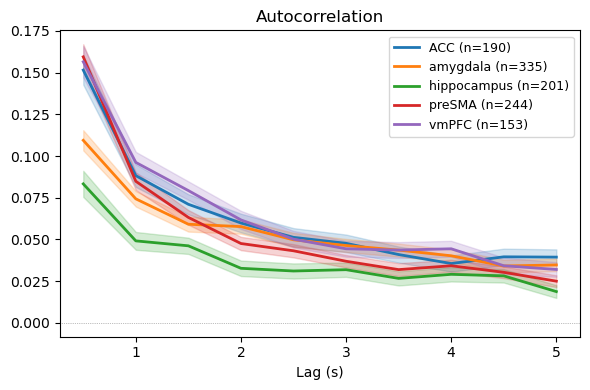

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))

for reg in sorted(set(regions)):
    reg_df = autocorrs_df[regions == reg]
    reg_mean, reg_sem = reg_df.mean(), reg_df.sem()
    line, = ax.plot(lags, reg_mean, linewidth=2, label=f'{reg} (n={len(reg_df)})')
    ax.fill_between(lags, reg_mean - reg_sem, reg_mean + reg_sem, alpha=0.2, color=line.get_color())

ax.axhline(0, color='gray', linewidth=0.5, linestyle=':')
ax.set(xlabel='Lag (s)', ylabel='', title='Autocorrelation')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()
